In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Carregar o dataset gerado pelo teu script de download
caminho = '../data/dataset.csv'

if os.path.exists(caminho):
    df = pd.read_csv(caminho).dropna()
    print(f"✅ Dataset carregado com sucesso! Total de textos: {len(df)}")
    print(f"Classes presentes: {df['label'].unique()}")
else:
    print("⚠️ ERRO: O dataset.csv não foi encontrado.")
    
df.head()

✅ Dataset carregado com sucesso! Total de textos: 67424
Classes presentes: ['openai' 'human' 'google' 'mistral' 'meta']


,text,label
0,"In a solar system, the star is the central bod...",openai
1,I'm assuming this is the US. Is this illegal? ...,human
2,Tattoos last a long time because the ink is in...,openai
3,"One knows that, the connected graded ring $P^{...",human
4,The detection of gravitational waves (GWs) gen...,human


Distribuição das classes:
label
openai     33087
human      32202
mistral      727
meta         717
google       691
Name: count, dtype: int64


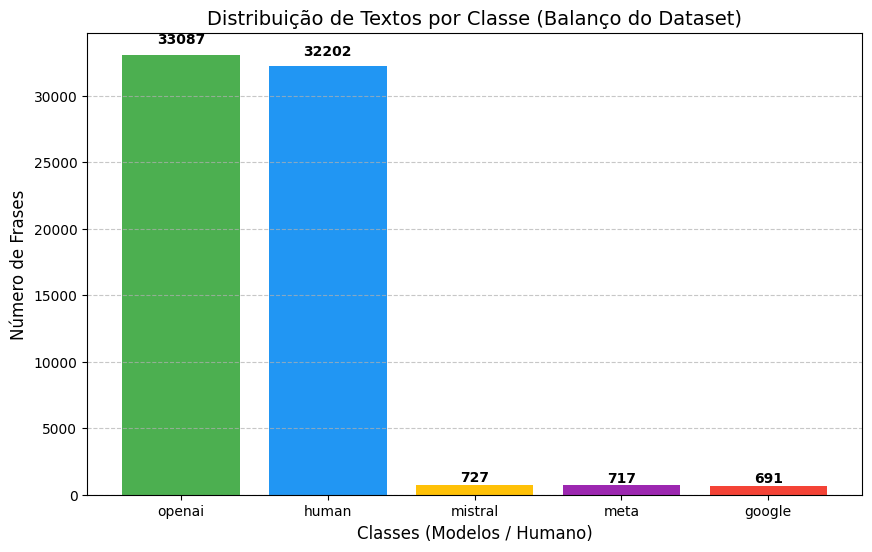

In [2]:
# Contar quantos textos temos de cada classe
contagem_classes = df['label'].value_counts()
print("Distribuição das classes:")
print(contagem_classes)

# Criar um gráfico de barras profissional
plt.figure(figsize=(10, 6))

# Lista de cores para as nossas 5 classes (Humano + 4 IAs)
cores = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#F44336']
bars = plt.bar(contagem_classes.index, contagem_classes.values, color=cores[:len(contagem_classes)])

# Adicionar o número exato em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), 
             ha='center', va='bottom', fontweight='bold')

plt.title('Distribuição de Textos por Classe (Balanço do Dataset)', fontsize=14)
plt.xlabel('Classes (Modelos / Humano)', fontsize=12)
plt.ylabel('Número de Frases', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

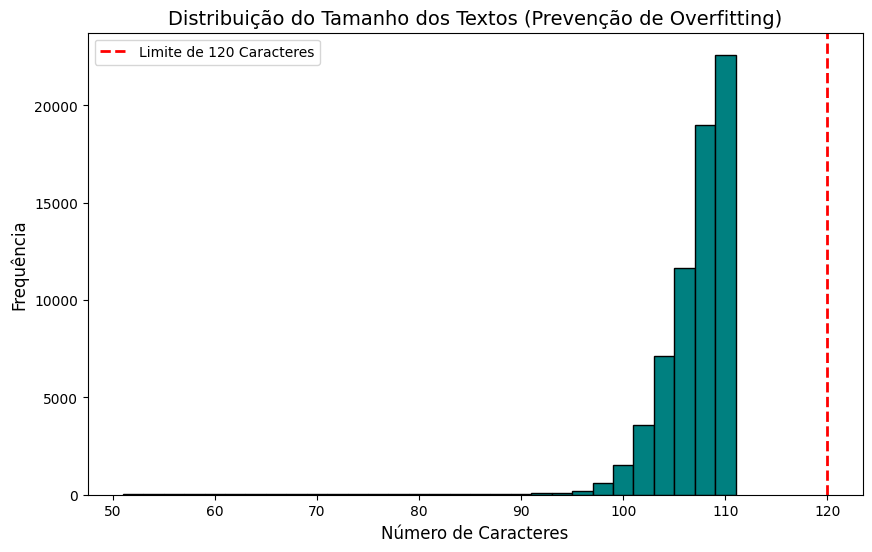

Tamanho médio dos textos: 106.3 caracteres
Tamanho máximo: 111 caracteres
Tamanho mínimo: 51 caracteres


In [3]:
# Calcular o tamanho de cada texto
df['tamanho_texto'] = df['text'].apply(lambda x: len(str(x)))

# Fazer um Histograma para mostrar a distribuição dos tamanhos
plt.figure(figsize=(10, 6))
plt.hist(df['tamanho_texto'], bins=30, color='teal', edgecolor='black')

# Adicionar a linha vermelha a marcar o limite (ex: 120 caracteres)
plt.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Limite de 120 Caracteres')

plt.title('Distribuição do Tamanho dos Textos (Prevenção de Overfitting)', fontsize=14)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.show()

# Imprimir as estatísticas finais
print(f"Tamanho médio dos textos: {df['tamanho_texto'].mean():.1f} caracteres")
print(f"Tamanho máximo: {df['tamanho_texto'].max()} caracteres")
print(f"Tamanho mínimo: {df['tamanho_texto'].min()} caracteres")